In [1]:
import pandas as pd

filepath = 'TransferSummary2.csv'
df = pd.read_csv(filepath)

C:\Users\nooro\AppData\Local\Temp\ipykernel_25424\2733241315.py:4: DtypeWarning: Columns (3,4,7,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

filepath = '/content/drive/MyDrive/UCBCRC_QuantCoreSummer2025/Distribution/TransferSummary2.csv'
df = pd.read_csv(filepath)

C:\Users\nooro\AppData\Local\Temp\ipykernel_81056\2315261564.py:3: DtypeWarning: Columns (3,4,7,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('TransferSummary2.csv', index_col=0)


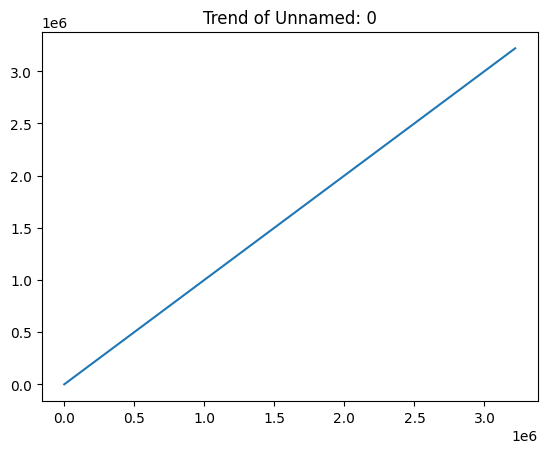

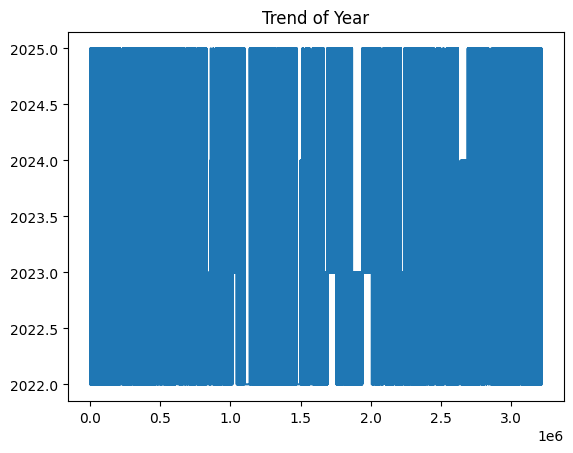

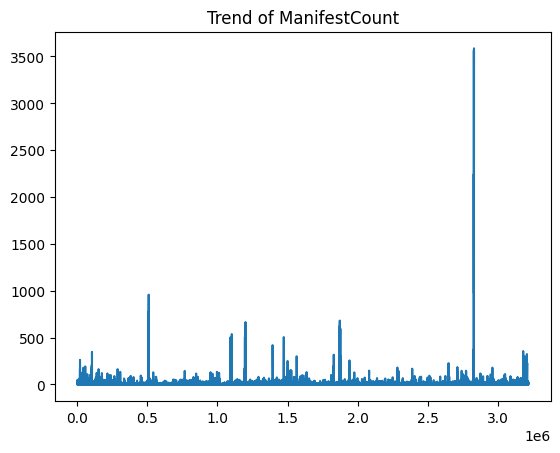

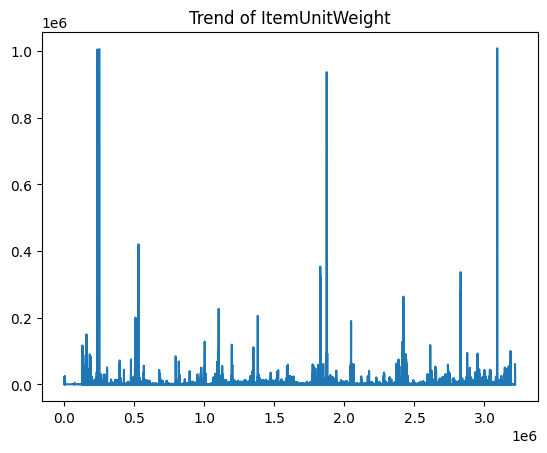

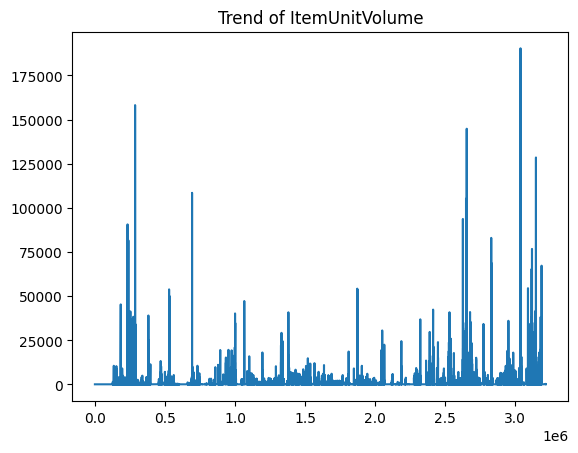

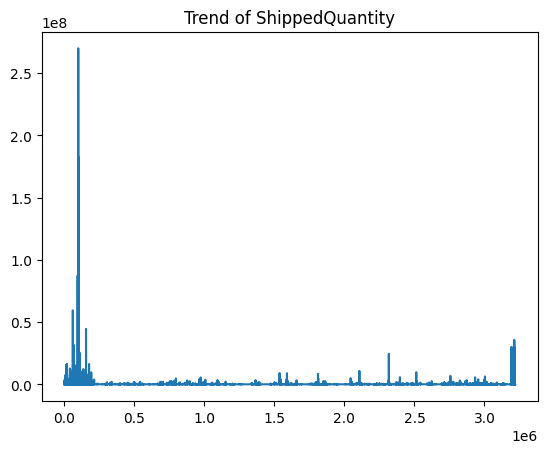

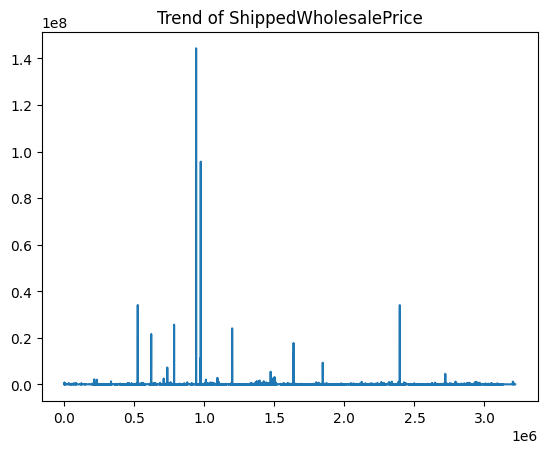

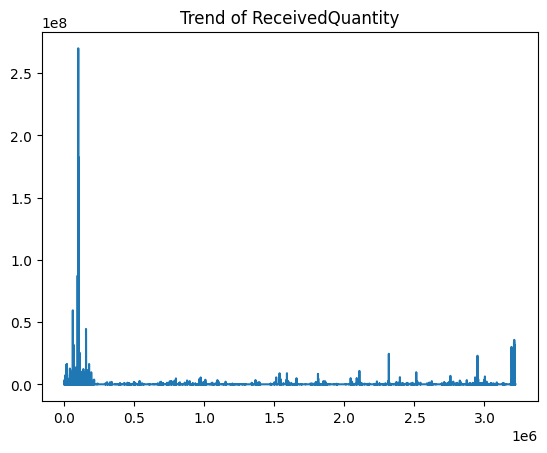

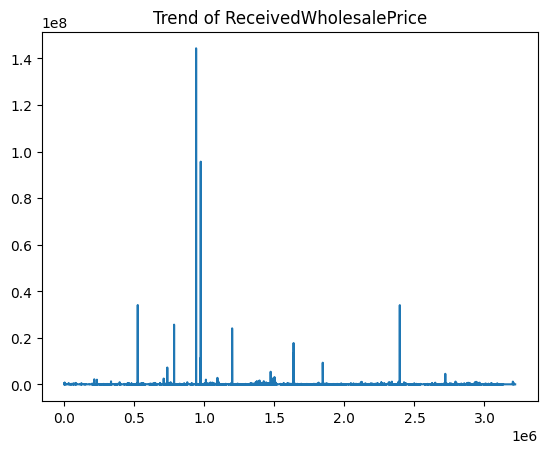

In [3]:
import matplotlib.pyplot as plt

for col in df.select_dtypes(include="number").columns:
    plt.figure()
    df[col].plot(title=f"Trend of {col}")
    plt.show()


In [ ]:
for col in df.columns:
    most_common = df[col].mode()[0]
    count = df[col].value_counts().iloc[0]
    print(f"{col}: '{most_common}' (repeated {count} times)")


OriginFacilityType: 'Cannabis - Distributor License' (repeated 2678195 times)
OriginCity: 'LOS ANGELES' (repeated 542927 times)
OriginZipCode: '94621.0' (repeated 145869 times)
OriginCounty: 'LOS ANGELES' (repeated 989078 times)
DestinationFacilityType: 'Cannabis - Retailer License' (repeated 2196058 times)
DestinationCity: 'LOS ANGELES' (repeated 363376 times)
DestinationZipCode: '94621' (repeated 20941 times)
DestinationCounty: 'LOS ANGELES' (repeated 687268 times)
ItemCategory: 'Flower (packaged eighth - each)' (repeated 408358 times)
ItemQuantityType: 'CountBased' (repeated 2983768 times)
ItemUnitWeightUOM: 'Grams' (repeated 2505423 times)
ItemUnitVolumeUOM: 'Milliliters' (repeated 159296 times)
ShippedUOM: 'Each' (repeated 2983768 times)
ReceivedUOM: 'Each' (repeated 2983768 times)
month: 'March' (repeated 344314 times)
Year: '2023' (repeated 1002297 times)
ManifestCount: '1' (repeated 2018248 times)
ItemUnitWeight: '0.0' (repeated 585506 times)
ItemUnitVolume: '0.0' (repeated 291

In [ ]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(15))



Column: OriginFacilityType
OriginFacilityType
Cannabis - Distributor License                2678195
Cannabis - Microbusiness License               267367
Cannabis - Retailer License                     40810
A-Nursery                                       29588
AM-Type 6: Non Volatile Solvent Extraction      29012
AM-Type 7: Volatile Solvent Extraction          24494
A-Processor                                     21134
A-Small Indoor                                  18694
A-Medium Indoor                                 12825
A-Specialty Indoor                              12627
AM-Type N: Infusion                             11211
M-Nursery                                        8199
A-Small Outdoor                                  7885
Cannabis - Retailer Nonstorefront License        7313
A-Small Mixed-Light Tier 1                       6454
Name: count, dtype: int64

Column: OriginCity
OriginCity
LOS ANGELES      542927
SACRAMENTO       182225
SANTA ROSA       176700
Oakland       

In [5]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)


                         Null Count     Null %
OriginFacilityType                1   0.000031
OriginCity                      100   0.003106
OriginZipCode                  6635   0.206113
OriginCounty                 878230  27.281840
DestinationFacilityType           1   0.000031
DestinationCity                 234   0.007269
DestinationZipCode             5221   0.162188
DestinationCounty            885176  27.497615
ItemCategory                      1   0.000031
ItemQuantityType                  1   0.000031
ItemUnitWeightUOM            585081  18.175292
ItemUnitVolumeUOM           2919581  90.695539
ShippedUOM                        1   0.000031
ReceivedUOM                       1   0.000031
month                             0   0.000000
Year                              0   0.000000
ManifestCount                     0   0.000000
ItemUnitWeight                    0   0.000000
ItemUnitVolume                    0   0.000000
ShippedQuantity                   0   0.000000
ShippedWholes

In [ ]:
import pandas as pd

weight_map = {
    "GRAMS": 1,
    "MILLIGRAMS": 0.001,
    "KILOGRAMS": 1000,
    "POUNDS": 453.592,
    "OUNCES": 28.3495
}

volume_map = {
    "MILLILITERS": 1,
    "LITERS": 1000,
    "FLUID OUNCES": 29.5735,
    "GALLONS": 3785.41,
    "QUARTS": 946.353
}

count_units = {"EACH"}

def convert_unit(value, unit, context="weight"):
    """
    value    : numeric value
    unit     : unit string
    context  : "weight", "volume", or "quantity" (shipped/received)
    """
    if pd.isna(value):
        return 0
    
    unit = str(unit).strip().upper()
    
    if context == "weight":
        if unit in weight_map:
            return value * weight_map[unit]
        else:
            return 0   
    
    if context == "volume":
        if unit in volume_map:
            return value * volume_map[unit]
        else:
            return 0   
    
    if context == "quantity":
        if unit in weight_map:
            return value * weight_map[unit]  
        elif unit in volume_map:
            return value * volume_map[unit]   
        elif unit in count_units:
            return value                      
        else:
            return 0
    
    return value


df["ItemUnitWeight"] = df.apply(
    lambda x: round(convert_unit(x["ItemUnitWeight"], x["ItemUnitWeightUOM"], "weight"), 2),
    axis=1
)

df["ItemUnitVolume"] = df.apply(
    lambda x: round(convert_unit(x["ItemUnitVolume"], x["ItemUnitVolumeUOM"], "volume"), 2),
    axis=1
)

df["ShippedQuantity"] = df.apply(
    lambda x: round(convert_unit(x["ShippedQuantity"], x["ShippedUOM"], "quantity"), 2),
    axis=1
)

df["ReceivedQuantity"] = df.apply(
    lambda x: round(convert_unit(x["ReceivedQuantity"], x["ReceivedUOM"], "quantity"), 2),
    axis=1
)

df = df.drop(columns=["ItemUnitWeightUOM", "ItemUnitVolumeUOM", "ShippedUOM", "ReceivedUOM"])


In [7]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

                         Null Count     Null %
OriginFacilityType                1   0.000031
OriginCity                      100   0.003106
OriginZipCode                  6635   0.206113
OriginCounty                 878230  27.281840
DestinationFacilityType           1   0.000031
DestinationCity                 234   0.007269
DestinationZipCode             5221   0.162188
DestinationCounty            885176  27.497615
ItemCategory                      1   0.000031
ItemQuantityType                  1   0.000031
month                             0   0.000000
Year                              0   0.000000
ManifestCount                     0   0.000000
ItemUnitWeight                    0   0.000000
ItemUnitVolume                    0   0.000000
ShippedQuantity                   0   0.000000
ShippedWholesalePrice             0   0.000000
ReceivedQuantity                  0   0.000000
ReceivedWholesalePrice            0   0.000000


In [8]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(15))


Column: OriginFacilityType
OriginFacilityType
Cannabis - Distributor License                2678195
Cannabis - Microbusiness License               267367
Cannabis - Retailer License                     40810
A-Nursery                                       29588
AM-Type 6: Non Volatile Solvent Extraction      29012
AM-Type 7: Volatile Solvent Extraction          24494
A-Processor                                     21134
A-Small Indoor                                  18694
A-Medium Indoor                                 12825
A-Specialty Indoor                              12627
AM-Type N: Infusion                             11211
M-Nursery                                        8199
A-Small Outdoor                                  7885
Cannabis - Retailer Nonstorefront License        7313
A-Small Mixed-Light Tier 1                       6454
Name: count, dtype: int64

Column: OriginCity
OriginCity
LOS ANGELES      542927
SACRAMENTO       182225
SANTA ROSA       176700
Oakland       

In [ ]:
mapping = df.loc[
    df["DestinationCity"].notna() &
    df["DestinationZipCode"].notna() &
    df["DestinationCounty"].notna(),
    ["DestinationCity", "DestinationZipCode", "DestinationCounty"]
].drop_duplicates()

city_to_zip_county = mapping.groupby("DestinationCity")[["DestinationZipCode", "DestinationCounty"]].first().to_dict("index")
zip_to_city_county = mapping.groupby("DestinationZipCode")[["DestinationCity", "DestinationCounty"]].first().to_dict("index")
county_to_city_zip = mapping.groupby("DestinationCounty")[["DestinationCity", "DestinationZipCode"]].first().to_dict("index")

def fill_destination(row):
    city, zipcode, county = row["DestinationCity"], row["DestinationZipCode"], row["DestinationCounty"]
    
    if pd.notna(city) and pd.notna(zipcode) and pd.notna(county):
        return row
    
    if pd.notna(city) and city in city_to_zip_county:
        ref_zip = city_to_zip_county[city]["DestinationZipCode"]
        ref_county = city_to_zip_county[city]["DestinationCounty"]
        if (pd.isna(zipcode) or zipcode == ref_zip) and (pd.isna(county) or county == ref_county):
            if pd.isna(zipcode): row["DestinationZipCode"] = ref_zip
            if pd.isna(county): row["DestinationCounty"] = ref_county
        return row
    
    if pd.notna(zipcode) and zipcode in zip_to_city_county:
        ref_city = zip_to_city_county[zipcode]["DestinationCity"]
        ref_county = zip_to_city_county[zipcode]["DestinationCounty"]
        if (pd.isna(city) or city == ref_city) and (pd.isna(county) or county == ref_county):
            if pd.isna(city): row["DestinationCity"] = ref_city
            if pd.isna(county): row["DestinationCounty"] = ref_county
        return row
    
    if pd.notna(county) and county in county_to_city_zip:
        ref_city = county_to_city_zip[county]["DestinationCity"]
        ref_zip = county_to_city_zip[county]["DestinationZipCode"]
        if (pd.isna(city) or city == ref_city) and (pd.isna(zipcode) or zipcode == ref_zip):
            if pd.isna(city): row["DestinationCity"] = ref_city
            if pd.isna(zipcode): row["DestinationZipCode"] = ref_zip
        return row
    
    return row

df = df.apply(fill_destination, axis=1)

In [10]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

                         Null Count     Null %
OriginFacilityType                1   0.000031
OriginCity                      100   0.003106
OriginZipCode                  6635   0.206113
OriginCounty                 878230  27.281840
DestinationFacilityType           1   0.000031
DestinationCity                   1   0.000031
DestinationZipCode              924   0.028704
DestinationCounty            727021  22.584597
ItemCategory                      1   0.000031
ItemQuantityType                  1   0.000031
month                             0   0.000000
Year                              0   0.000000
ManifestCount                     0   0.000000
ItemUnitWeight                    0   0.000000
ItemUnitVolume                    0   0.000000
ShippedQuantity                   0   0.000000
ShippedWholesalePrice             0   0.000000
ReceivedQuantity                  0   0.000000
ReceivedWholesalePrice            0   0.000000


In [ ]:
mapping = df.loc[
    df["DestinationCity"].notna() &
    df["DestinationZipCode"].notna() &
    df["DestinationCounty"].notna(),
    ["DestinationCity", "DestinationZipCode", "DestinationCounty"]
].drop_duplicates()

city_to_zip_county = mapping.groupby("DestinationCity")[["DestinationZipCode", "DestinationCounty"]].first().to_dict("index")
zip_to_city_county = mapping.groupby("DestinationZipCode")[["DestinationCity", "DestinationCounty"]].first().to_dict("index")
county_to_city_zip = mapping.groupby("DestinationCounty")[["DestinationCity", "DestinationZipCode"]].first().to_dict("index")

def fill_zip_from_city(row):
    city, zipcode = row["DestinationCity"], row["DestinationZipCode"]

    if pd.notna(city) and pd.isna(zipcode):
        if city in city_to_zip_county:
            ref_zip = city_to_zip_county[city]["DestinationZipCode"]
            row["DestinationZipCode"] = ref_zip
    return row

df = df.apply(fill_zip_from_city, axis=1)

In [12]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

                         Null Count     Null %
OriginFacilityType                1   0.000031
OriginCity                      100   0.003106
OriginZipCode                  6635   0.206113
OriginCounty                 878230  27.281840
DestinationFacilityType           1   0.000031
DestinationCity                   1   0.000031
DestinationZipCode                8   0.000249
DestinationCounty            727021  22.584597
ItemCategory                      1   0.000031
ItemQuantityType                  1   0.000031
month                             0   0.000000
Year                              0   0.000000
ManifestCount                     0   0.000000
ItemUnitWeight                    0   0.000000
ItemUnitVolume                    0   0.000000
ShippedQuantity                   0   0.000000
ShippedWholesalePrice             0   0.000000
ReceivedQuantity                  0   0.000000
ReceivedWholesalePrice            0   0.000000


In [ ]:
def check_city_based_fills(df, city_to_zip_county, zip_to_city_county):
    results = []

    for idx, row in df.iterrows():
        city, zipcode, county = row["DestinationCity"], row["DestinationZipCode"], row["DestinationCounty"]

        if pd.notna(city) and city in city_to_zip_county and (pd.isna(zipcode) or pd.isna(county)):
            ref_zip = city_to_zip_county[city]["DestinationZipCode"]
            ref_county = city_to_zip_county[city]["DestinationCounty"]

            conflict = False
            conflict_reason = []

            if pd.notna(zipcode) and zipcode != ref_zip:
                conflict = True
                conflict_reason.append(f"Zip conflict: given={zipcode}, expected={ref_zip}")

            if pd.notna(county) and county != ref_county:
                conflict = True
                conflict_reason.append(f"County conflict: given={county}, expected={ref_county}")

            if conflict:
                results.append({
                    "Row": idx,
                    "City": city,
                    "Zip": zipcode,
                    "County": county,
                    "Conflict": "; ".join(conflict_reason)
                })
            else:
                results.append({
                    "Row": idx,
                    "City": city,
                    "Zip": zipcode if pd.notna(zipcode) else f"(will fill {ref_zip})",
                    "County": county if pd.notna(county) else f"(will fill {ref_county})",
                    "Conflict": None
                })

    return pd.DataFrame(results)


In [14]:
conflict_report = check_city_based_fills(df, city_to_zip_county, zip_to_city_county)


In [ ]:
cols_to_check = [
    "DestinationFacilityType",
    "DestinationCity",
    "DestinationZipCode",
    "DestinationCounty",
    "ItemCategory",
    "ItemQuantityType"
]

df = df.dropna(subset=cols_to_check)


In [16]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

                         Null Count    Null %
OriginFacilityType                0  0.000000
OriginCity                       76  0.003050
OriginZipCode                  6031  0.242007
OriginCounty                 235827  9.463086
DestinationFacilityType           0  0.000000
DestinationCity                   0  0.000000
DestinationZipCode                0  0.000000
DestinationCounty                 0  0.000000
ItemCategory                      0  0.000000
ItemQuantityType                  0  0.000000
month                             0  0.000000
Year                              0  0.000000
ManifestCount                     0  0.000000
ItemUnitWeight                    0  0.000000
ItemUnitVolume                    0  0.000000
ShippedQuantity                   0  0.000000
ShippedWholesalePrice             0  0.000000
ReceivedQuantity                  0  0.000000
ReceivedWholesalePrice            0  0.000000


In [ ]:
origin_mapping = df.loc[
    df["OriginCity"].notna() &
    df["OriginZipCode"].notna() &
    df["OriginCounty"].notna(),
    ["OriginCity", "OriginZipCode", "OriginCounty"]
].drop_duplicates()

origin_city_to_zip_county = origin_mapping.groupby("OriginCity")[["OriginZipCode", "OriginCounty"]].first().to_dict("index")
origin_zip_to_city_county = origin_mapping.groupby("OriginZipCode")[["OriginCity", "OriginCounty"]].first().to_dict("index")
origin_county_to_city_zip = origin_mapping.groupby("OriginCounty")[["OriginCity", "OriginZipCode"]].first().to_dict("index")

def fill_origin(row):
    city, zipcode, county = row["OriginCity"], row["OriginZipCode"], row["OriginCounty"]
    
    if pd.notna(city) and pd.notna(zipcode) and pd.notna(county):
        return row
    
    if pd.notna(city) and city in origin_city_to_zip_county:
        ref_zip = origin_city_to_zip_county[city]["OriginZipCode"]
        ref_county = origin_city_to_zip_county[city]["OriginCounty"]
        if (pd.isna(zipcode) or zipcode == ref_zip) and (pd.isna(county) or county == ref_county):
            if pd.isna(zipcode): row["OriginZipCode"] = ref_zip
            if pd.isna(county): row["OriginCounty"] = ref_county
        return row
    
    if pd.notna(zipcode) and zipcode in origin_zip_to_city_county:
        ref_city = origin_zip_to_city_county[zipcode]["OriginCity"]
        ref_county = origin_zip_to_city_county[zipcode]["OriginCounty"]
        if (pd.isna(city) or city == ref_city) and (pd.isna(county) or county == ref_county):
            if pd.isna(city): row["OriginCity"] = ref_city
            if pd.isna(county): row["OriginCounty"] = ref_county
        return row
    
    if pd.notna(county) and county in origin_county_to_city_zip:
        ref_city = origin_county_to_city_zip[county]["OriginCity"]
        ref_zip = origin_county_to_city_zip[county]["OriginZipCode"]
        if (pd.isna(city) or city == ref_city) and (pd.isna(zipcode) or zipcode == ref_zip):
            if pd.isna(city): row["OriginCity"] = ref_city
            if pd.isna(zipcode): row["OriginZipCode"] = ref_zip
        return row
    
    return row

df = df.apply(fill_origin, axis=1)


def fill_origin_zip_from_city(row):
    city, zipcode = row["OriginCity"], row["OriginZipCode"]

    if pd.notna(city) and pd.isna(zipcode):
        if city in origin_city_to_zip_county:
            ref_zip = origin_city_to_zip_county[city]["OriginZipCode"]
            row["OriginZipCode"] = ref_zip
    return row

df = df.apply(fill_origin_zip_from_city, axis=1)


In [18]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

                         Null Count    Null %
OriginFacilityType                0  0.000000
OriginCity                        0  0.000000
OriginZipCode                    29  0.001164
OriginCounty                 223537  8.969922
DestinationFacilityType           0  0.000000
DestinationCity                   0  0.000000
DestinationZipCode                0  0.000000
DestinationCounty                 0  0.000000
ItemCategory                      0  0.000000
ItemQuantityType                  0  0.000000
month                             0  0.000000
Year                              0  0.000000
ManifestCount                     0  0.000000
ItemUnitWeight                    0  0.000000
ItemUnitVolume                    0  0.000000
ShippedQuantity                   0  0.000000
ShippedWholesalePrice             0  0.000000
ReceivedQuantity                  0  0.000000
ReceivedWholesalePrice            0  0.000000


In [ ]:
cols_to_check = [
    "OriginZipCode",
    "OriginCounty"
]

df = df.dropna(subset=cols_to_check)

In [20]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Null %": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

                         Null Count  Null %
OriginFacilityType                0     0.0
OriginCity                        0     0.0
OriginZipCode                     0     0.0
OriginCounty                      0     0.0
DestinationFacilityType           0     0.0
DestinationCity                   0     0.0
DestinationZipCode                0     0.0
DestinationCounty                 0     0.0
ItemCategory                      0     0.0
ItemQuantityType                  0     0.0
month                             0     0.0
Year                              0     0.0
ManifestCount                     0     0.0
ItemUnitWeight                    0     0.0
ItemUnitVolume                    0     0.0
ShippedQuantity                   0     0.0
ShippedWholesalePrice             0     0.0
ReceivedQuantity                  0     0.0
ReceivedWholesalePrice            0     0.0


In [21]:
df.columns

Index(['OriginFacilityType', 'OriginCity', 'OriginZipCode', 'OriginCounty',
       'DestinationFacilityType', 'DestinationCity', 'DestinationZipCode',
       'DestinationCounty', 'ItemCategory', 'ItemQuantityType', 'month',
       'Year', 'ManifestCount', 'ItemUnitWeight', 'ItemUnitVolume',
       'ShippedQuantity', 'ShippedWholesalePrice', 'ReceivedQuantity',
       'ReceivedWholesalePrice'],
      dtype='object')

In [ ]:
import re

def to_snake_case(name):
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name).lower()
    return name

df.columns = [to_snake_case(col) for col in df.columns]

In [23]:
df.columns

Index(['origin_facility_type', 'origin_city', 'origin_zip_code',
       'origin_county', 'destination_facility_type', 'destination_city',
       'destination_zip_code', 'destination_county', 'item_category',
       'item_quantity_type', 'month', 'year', 'manifest_count',
       'item_unit_weight', 'item_unit_volume', 'shipped_quantity',
       'shipped_wholesale_price', 'received_quantity',
       'received_wholesale_price'],
      dtype='object')

In [ ]:
from difflib import SequenceMatcher

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

threshold = 0.85

cols_to_check = [
    col for col in df.select_dtypes(exclude=['int64', 'float64']).columns
    if "zip" not in col.lower()
]

for col in cols_to_check:
    values = df[col].dropna().unique()
    checked = set()
    print(f"\n🔍 Checking column: {col}")
    for i, v1 in enumerate(values):
        for v2 in values[i+1:]:
            if (v1, v2) not in checked and (v2, v1) not in checked:
                score = SequenceMatcher(None, str(v1), str(v2)).ratio()
                if score >= threshold and v1 != v2:
                    print(f"  '{v1}'  ↔  '{v2}'  | Similarity: {round(score,3)}")
                checked.add((v1, v2))



🔍 Checking column: origin_facility_type
  'A-Large Indoor'  ↔  'M-Large Indoor'  | Similarity: 0.929
  'A-Large Mixed-Light Tier 1'  ↔  'A-Large Mixed-Light Tier 2'  | Similarity: 0.962
  'A-Large Mixed-Light Tier 1'  ↔  'M-Large Mixed-Light Tier 1'  | Similarity: 0.962
  'A-Large Mixed-Light Tier 1'  ↔  'M-Large Mixed-Light Tier 2'  | Similarity: 0.923
  'A-Large Mixed-Light Tier 2'  ↔  'M-Large Mixed-Light Tier 1'  | Similarity: 0.923
  'A-Large Mixed-Light Tier 2'  ↔  'M-Large Mixed-Light Tier 2'  | Similarity: 0.962
  'A-Large Outdoor'  ↔  'M-Large Outdoor'  | Similarity: 0.933
  'A-Medium Indoor'  ↔  'M-Medium Indoor'  | Similarity: 0.933
  'A-Medium Mixed-Light Tier 1'  ↔  'A-Medium Mixed-Light Tier 2'  | Similarity: 0.963
  'A-Medium Mixed-Light Tier 1'  ↔  'M-Medium Mixed-Light Tier 1'  | Similarity: 0.963
  'A-Medium Mixed-Light Tier 1'  ↔  'M-Medium Mixed-Light Tier 2'  | Similarity: 0.926
  'A-Medium Mixed-Light Tier 2'  ↔  'M-Medium Mixed-Light Tier 1'  | Similarity: 0.926

In [ ]:
city_corrections = {
    "Desert hot Springs": "Desert Hot Springs",
    "oakland": "Oakland",
    "sacramento": "Sacramento",
    "San Bernadino": "San Bernardino",
    "willits": "Willits",
    "fortuna": "Fortuna",
    "King CIty": "King City",
    "isleton": "Isleton",
    "Rdwood Valley": "Redwood Valley",
    "laytonville": "Laytonville",
    "CATHEDRAL CTY": "CATHEDRAL CITY",
    "Mt Shasta": "Mount Shasta",
    "W SACRAMENTO": "WEST SACRAMENTO",  
    "Costs Mesa": "Costa Mesa",
    "HUNTINGTON PK": "HUNTINGTON PARK",
    "N HOLLYWOOD": "North Hollywood",  
    "W HOLLYWOOD": "West Hollywood",
    "WOODLAND HLS": "WOODLAND HILLS",
    "REDWOOD VLY": "REDWOOD VALLEY",
    "PHILLIPSVILLE": "PHILIPSVILLE",
    "SHINGLE SPGS": "SHINGLE SPRINGS",
    "SN BERNRDNO": "San Bernardino",
    "WEST SACRAMENTO": "WEST SACRAMENTO", 
    "S LAKE TAHOE": "SOUTH LAKE TAHOE",
    "MARINA DL REY": "MARINA DEL REY",
    "SN LUIS OBISP": "SAN LUIS OBISPO",
}
df["origin_city"] = df["origin_city"].replace(city_corrections)

destination_city_corrections = {
    "CATHEDRAL CTY": "CATHEDRAL CITY",
    "Costs Mesa": "Costa Mesa",
    "HUNTINGTON PK": "HUNTINGTON PARK",
    "sacramento": "Sacramento",
    "SACRAMENTO": "Sacramento",   
    "W SACRAMENTO": "West Sacramento",  
    "REDWOOD VLY": "Redwood Valley",
    "SN BERNRDNO": "San Bernardino",
    "oakland": "Oakland",
    "Desert hot Springs": "Desert Hot Springs",
    "King CIty": "King City",
    "isleton": "Isleton",
    "willits": "Willits",
    "laytonville": "Laytonville",
    "UNION CITY": "Union City",   
    "JUNCTION CITY": "Junction City",
    "SMARTSVILLE": "Smartsville",
    "MARYSVILLE": "Marysville",
    "S LAKE TAHOE": "South Lake Tahoe",
    "PHILLIPSVILLE": "Phillipsville",
    "fortuna": "Fortuna",
    "Rdwood Valley": "Redwood Valley",
    "San Bernadino": "San Bernardino",
    "Mt Shasta": "Mount Shasta",
    "WOODLAND HLS": "Woodland Hills",
    "SN LUIS OBISP": "San Luis Obispo",
    "SHINGLE SPGS": "Shingle Springs",
    "MARINA DL REY": "Marina Del Rey",
    "N HOLLYWOOD": "North Hollywood",
    "W HOLLYWOOD": "West Hollywood",
    "HOLLYWOOD": "Hollywood",
    "South lake tahoe": "South Lake Tahoe",
}
df["destination_city"] = df["destination_city"].replace(destination_city_corrections)


In [ ]:
from difflib import SequenceMatcher

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

threshold = 0.85

cols_to_check = [
    col for col in df.select_dtypes(exclude=['int64', 'float64']).columns
    if "zip" not in col.lower()
]

for col in cols_to_check:
    values = df[col].dropna().unique()
    checked = set()
    print(f"\n🔍 Checking column: {col}")
    for i, v1 in enumerate(values):
        for v2 in values[i+1:]:
            if (v1, v2) not in checked and (v2, v1) not in checked:
                score = SequenceMatcher(None, str(v1), str(v2)).ratio()
                if score >= threshold and v1 != v2:
                    print(f"  '{v1}'  ↔  '{v2}'  | Similarity: {round(score,3)}")
                checked.add((v1, v2))



🔍 Checking column: origin_facility_type
  'A-Large Indoor'  ↔  'M-Large Indoor'  | Similarity: 0.929
  'A-Large Mixed-Light Tier 1'  ↔  'A-Large Mixed-Light Tier 2'  | Similarity: 0.962
  'A-Large Mixed-Light Tier 1'  ↔  'M-Large Mixed-Light Tier 1'  | Similarity: 0.962
  'A-Large Mixed-Light Tier 1'  ↔  'M-Large Mixed-Light Tier 2'  | Similarity: 0.923
  'A-Large Mixed-Light Tier 2'  ↔  'M-Large Mixed-Light Tier 1'  | Similarity: 0.923
  'A-Large Mixed-Light Tier 2'  ↔  'M-Large Mixed-Light Tier 2'  | Similarity: 0.962
  'A-Large Outdoor'  ↔  'M-Large Outdoor'  | Similarity: 0.933
  'A-Medium Indoor'  ↔  'M-Medium Indoor'  | Similarity: 0.933
  'A-Medium Mixed-Light Tier 1'  ↔  'A-Medium Mixed-Light Tier 2'  | Similarity: 0.963
  'A-Medium Mixed-Light Tier 1'  ↔  'M-Medium Mixed-Light Tier 1'  | Similarity: 0.963
  'A-Medium Mixed-Light Tier 1'  ↔  'M-Medium Mixed-Light Tier 2'  | Similarity: 0.926
  'A-Medium Mixed-Light Tier 2'  ↔  'M-Medium Mixed-Light Tier 1'  | Similarity: 0.926

In [ ]:
from difflib import SequenceMatcher
import itertools

def compare_columns_similarity(df, col1, col2, threshold=0.85):
    """
    Compare values between two columns and print similar matches.

    Parameters:
        df (pd.DataFrame): The dataframe
        col1, col2 (str): Column names to compare
        threshold (float): Similarity cutoff (0.0–1.0)
    """
    print(f"\n🔍 Comparing {col1} ↔ {col2}")
    
    unique1 = df[col1].dropna().unique()
    unique2 = df[col2].dropna().unique()
    


    for a, b in itertools.product(unique1, unique2):
        ratio = SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()
        if ratio >= threshold and a != b:
            print(f"  '{a}'  ↔  '{b}'  | Similarity: {round(ratio,3)}")

compare_columns_similarity(df, "origin_city", "destination_city", threshold=0.85)



🔍 Comparing origin_city ↔ destination_city
  'Cathedral City'  ↔  'CATHEDRAL CITY'  | Similarity: 1.0
  'Richmond'  ↔  'RICHMOND'  | Similarity: 1.0
  'Watsonville'  ↔  'WATSONVILLE'  | Similarity: 1.0
  'Rio Dell'  ↔  'RIO DELL'  | Similarity: 1.0
  'Clearlake'  ↔  'CLEARLAKE'  | Similarity: 1.0
  'Coachella'  ↔  'COACHELLA'  | Similarity: 1.0
  'Lompoc'  ↔  'LOMPOC'  | Similarity: 1.0
  'Lompoc'  ↔  'lompoc'  | Similarity: 1.0
  'Adelanto'  ↔  'ADELANTO'  | Similarity: 1.0
  'California City'  ↔  'CALIFORNIA CITY'  | Similarity: 1.0
  'Coalinga'  ↔  'COALINGA'  | Similarity: 1.0
  'Colusa'  ↔  'COLUSA'  | Similarity: 1.0
  'Commerce'  ↔  'COMMERCE'  | Similarity: 1.0
  'Desert Hot Springs'  ↔  'DESERT HOT SPRINGS'  | Similarity: 1.0
  'Greenfield'  ↔  'GREENFIELD'  | Similarity: 1.0
  'Hollister'  ↔  'HOLLISTER'  | Similarity: 1.0
  'LOS ANGELES'  ↔  'Los Angeles'  | Similarity: 1.0
  'LOS ANGELES'  ↔  'los angeles'  | Similarity: 1.0
  'Lancaster'  ↔  'LANCASTER'  | Similarity: 1.0

In [41]:
def convert_to_title_case(df, col1="origin_city", col2="destination_city"):
    """
    Convert the two city columns to title case (e.g., 'LOS ANGELES' → 'Los Angeles').

    Parameters:
        df (pd.DataFrame): Dataframe with city columns
        col1, col2 (str): Column names to normalize

    Returns:
        pd.DataFrame: New dataframe with updated city names
    """
    df[col1] = df[col1].astype(str).str.title()
    df[col2] = df[col2].astype(str).str.title()
    return df

df = convert_to_title_case(df)

In [42]:
corrections = {
    "Philipsville": "Phillipsville"
}

df["origin_city"] = df["origin_city"].replace(corrections)
df["destination_city"] = df["destination_city"].replace(corrections)


In [43]:
compare_columns_similarity(df, "origin_city", "destination_city", threshold=0.85)


🔍 Comparing origin_city ↔ destination_city
  'Marysville'  ↔  'Smartsville'  | Similarity: 0.857
  'Junction City'  ↔  'Union City'  | Similarity: 0.87
  'Smartsville'  ↔  'Marysville'  | Similarity: 0.857
  'Union City'  ↔  'Junction City'  | Similarity: 0.87


In [ ]:
import re

df["origin_county"] = df["origin_county"].str.replace(r"\bCounty\b", "", flags=re.IGNORECASE, regex=True).str.strip()
df["destination_county"] = df["destination_county"].str.replace(r"\bCounty\b", "", flags=re.IGNORECASE, regex=True).str.strip()


In [46]:
def convert_to_title_case(df, col1="origin_county", col2="destination_county"):
    """
    Convert the two city columns to title case (e.g., 'LOS ANGELES' → 'Los Angeles').

    Parameters:
        df (pd.DataFrame): Dataframe with city columns
        col1, col2 (str): Column names to normalize

    Returns:
        pd.DataFrame: New dataframe with updated city names
    """
    df[col1] = df[col1].astype(str).str.title()
    df[col2] = df[col2].astype(str).str.title()
    return df

df = convert_to_title_case(df)

In [48]:

cols_to_drop = ['item_unit_volume', 'item_unit_weight', 'manifest_count', 'destination_zip_code', 'origin_zip_code']
df = df.drop(columns=cols_to_drop)
df.to_csv("cleaned.csv", index=False)